# 03E · Train the multilingual NLI classifier (4 tasks, bilingual) — TRAIN ONLY

Fine-tune **`MoritzLaurer/bge-m3-zeroshot-v2.0`** (large, multilingual NLI) with the
**Political DEBATE** recipe into ONE entailment model that covers four tasks:

| Task | Label space | Hypothesis template |
|---|---|---|
| **T1 topic** (binary) | Economy / Society | `This text is about {the state and the economy / political institutions and society}.` |
| **T2 econ stance** (Economy) | State / Market / Neutral | `This text expresses {…} on economic issues.` |
| **T3 soc stance** (Society) | Progressive / Conservative / Neutral | `This text expresses a {…} stance on social issues.` |
| **T4 general stance** (all) | Left / Right / Neutral | `This text expresses a {leftist/rightist/neutral} political stance.` |

**T4 is the production target** (`Left = state+progressive`, `Right = market+conservative`);
its wording is what the **inference notebook (06)** uses.

* **NLI / entailment**, **binary head** `{0:entailment, 1:not_entailment}`
  (neutral+contradiction collapsed; DEBATE §3.2 fn 1), warm-started from XLM-R's
  3-class XNLI head (entailment→0, contradiction→1).
* **Premise = sentence text; speaker-blind** (never party/candidate/country).
* **Bilingual augmentation:** every labelled sentence is used in BOTH its original
  language (`text`) and the English MT (`text_en`, where present) — augmentation +
  cross-lingual alignment. Pair counts (original / translation / both) are reported.
* For each sentence the gold hypothesis = *entail*, the other label hypotheses =
  *not-entail*. **Split by `manifesto_id`** (no leakage) BEFORE building pairs.
* DEBATE hyperparameters; per-epoch eval + load-best + early stopping; `fp16`.
* Reports **macro-F1 per language and per L/R/N** on a held-out test set.

Progress bars on every long step (pair build, training, evaluation).
Granular cells: expensive compute is isolated from plotting/printing.

## 1 · Preamble — mount, seed, GPU assert
Colab has the needed packages; this notebook does not pip-install.

In [1]:
# Install paper-figure fonts (run once): TeX Gyre Heros (Helvetica clone) + Latin Modern Sans.
# Figures use matplotlib's font manager + mathtext (NOT usetex), so only the system font
# FILES are needed -- the TeX 'lmodern' *package* itself is not required for rendering.
!apt-get -qq update >/dev/null 2>&1; apt-get -qq install -y fonts-texgyre fonts-lmodern >/dev/null 2>&1
import glob as _g
print('TeX Gyre Heros present:',
      bool(_g.glob('/usr/share/texmf*/**/texgyreheros-*.otf', recursive=True)))

TeX Gyre Heros present: True


In [2]:
# === TRAIN notebook ===
import os, sys, gc, json, random, re
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT = Path('/content/drive/MyDrive/Papers/transfer_learning')
except Exception:
    REPO    = Path(os.getenv('TOPIC2IRT_ROOT', r'G:/My Drive/Papers/transfer_learning/topic2irt'))
    PROJECT = REPO.parent      # local fallback
REPO = PROJECT / 'topic2irt'
assert REPO.exists(), f'REPO not found: {REPO}'

RANDOM_STATE = 14605 - 2025 - 4        # = 12576
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)

import torch
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
assert torch.cuda.is_available(), 'Select a GPU runtime (L4/A100 + High-RAM).'
print('torch       :', torch.__version__)
print('device      :', torch.cuda.get_device_name(0))
print('CUDA mem GB :', round(torch.cuda.get_device_properties(0).total_memory/1e9, 1))
print('REPO        :', REPO, '| RANDOM_STATE:', RANDOM_STATE)

Mounted at /content/drive
torch       : 2.11.0+cu128
device      : NVIDIA A100-SXM4-80GB
CUDA mem GB : 85.1
REPO        : /content/drive/MyDrive/Papers/transfer_learning/topic2irt | RANDOM_STATE: 12576


## 2 · Config — model, hyperparameters, switches

In [3]:
MODEL_NAME = 'MoritzLaurer/bge-m3-zeroshot-v2.0'   # XLM-R-based (robust, fp16-safe), multilingual, 2-class entail/not-entail
MAX_LENGTH = 192

# DEBATE / Laurer TrainingArguments. LR: tuned 9e-6 at eff-batch 32; sqrt-scaled to
# 1.3e-5 for the eff-batch 64 production run (sqrt(64/32)*9e-6 ~= 1.27e-5).
LR            = 1.3e-5
EPOCHS        = 20           # hard cap (insurance); early-stop patience-3 @ eval-2000 binds ~epoch 2-4
WARMUP_RATIO  = 0.06
WEIGHT_DECAY  = 0.01

# --- Batch size from VRAM (~0.6B model). Effective batch 64 (sqrt-LR-scaled). ---
# bge-m3 @ len 192: ~12GB fixed + ~0.23GB/sample -> per-device 64 ~= 27GB (fits 40/80GB A100, accum 1).
EFF_BATCH = 64
_gpu_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
PER_DEVICE = 64 if _gpu_gb >= 38 else 32 if _gpu_gb >= 22 else 16 if _gpu_gb >= 14 else 8
TRAIN_BS   = min(PER_DEVICE, EFF_BATCH)
GRAD_ACCUM = max(1, EFF_BATCH // TRAIN_BS)
EVAL_BS    = PER_DEVICE * 4
print(f'GPU {_gpu_gb:.0f}GB -> per-device {TRAIN_BS} x accum {GRAD_ACCUM} = eff {TRAIN_BS*GRAD_ACCUM} | eval_bs {EVAL_BS}')

# Eval/save every ~0.5 epoch so best-checkpoint selection resolves the 2-3 epoch optimum;
# patience 3 = ~1.5 epochs of no val-MCC gain before stopping.
EVAL_SAVE_STEPS = dict(full=2000, smoke=25)
LOG_STEPS       = dict(full=250,  smoke=10)
PATIENCE        = dict(full=3,    smoke=3)

OVERSAMPLE   = True
NEGATIVES    = 'one'          # balanced 1:1 entail:not-entail
USE_ENGLISH  = True

SMOKE           = False
SMOKE_PER_CLASS = 100

FRAME_CSV = REPO / 'data/processed/stance_nli_training_frame.csv'
MODEL_DIR = REPO / 'models/stance_nli_bgem3'
TEST_PRED = REPO / 'data/processed/stance_nli_test_predictions.csv'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print('model:', MODEL_NAME, '| SMOKE:', SMOKE, '| LR:', LR, '| NEGATIVES:', NEGATIVES,
      '| OVERSAMPLE:', OVERSAMPLE, '| USE_ENGLISH:', USE_ENGLISH)

GPU 85GB -> per-device 64 x accum 1 = eff 64 | eval_bs 256
model: MoritzLaurer/bge-m3-zeroshot-v2.0 | SMOKE: False | LR: 1.3e-05 | NEGATIVES: one | OVERSAMPLE: True | USE_ENGLISH: True


In [4]:
# --- The four NLI tasks (one pooled entailment model) ------------------------
# Each option string is substituted into the task template to form a hypothesis.
# Dict insertion order fixes the argmax label order at inference.
TASKS = {
    'topic': dict(
        col='topic_label',
        template='This text is about {}.',
        options={'Economy': 'the state and the economy',
                 'Society': 'political institutions and society'}),
    'econ': dict(
        col='econ_label',
        template='This text expresses {} on economic issues.',
        options={'State':   'a stance supporting state intervention and redistribution',
                 'Market':  'a stance supporting free markets and growth',
                 'Neutral': 'a neutral stance'}),
    'soc': dict(
        col='soc_label',
        template='This text expresses a {} stance on social issues.',
        options={'Progressive': 'progressive',
                 'Conservative': 'conservative',
                 'Neutral': 'neutral'}),
    'general': dict(   # <-- production target; this wording is used at inference
        col='gen_label',
        template='This text expresses a {} political stance.',
        options={'Left': 'leftist', 'Right': 'rightist', 'Neutral': 'neutral'}),
}

def hyp(task, label):
    t = TASKS[task]
    return t['template'].format(t['options'][label])

LRN_ORDER = ['Left', 'Right', 'Neutral']                 # general-stance order
GEN_HYPS  = [hyp('general', c) for c in LRN_ORDER]        # the 3 production hypotheses
print('Production (general-stance) hypotheses:')
for c, h in zip(LRN_ORDER, GEN_HYPS):
    print(f'  {c:<8} -> "{h}"')

Production (general-stance) hypotheses:
  Left     -> "This text expresses a leftist political stance."
  Right    -> "This text expresses a rightist political stance."
  Neutral  -> "This text expresses a neutral political stance."


## 3 · Load the multi-task frame

In [5]:
frame = pd.read_csv(FRAME_CSV, dtype={'sid': str})
frame['text'] = frame['text'].astype(str)
frame['text_en'] = frame['text_en'].astype('string')
for t in TASKS:
    col = TASKS[t]['col']
    n = frame[col].notna().sum()
    vc = frame[col].value_counts().to_dict()
    print(f'{t:<8} ({col:<11}) labelled={n:>6,}  {vc}')
print('\\nrows:', f'{len(frame):,}', '| manifestos:', frame['manifesto_id'].nunique(),
      '| languages:', frame['language'].nunique(),
      '| with text_en:', int(frame['text_en'].str.strip().fillna('').ne('').sum()))

topic    (topic_label) labelled=38,592  {'Economy': 22006, 'Society': 16586}
econ     (econ_label ) labelled=11,325  {'State': 5527, 'Market': 3331, 'Neutral': 2467}
soc      (soc_label  ) labelled= 9,855  {'Progressive': 4006, 'Neutral': 3019, 'Conservative': 2830}
general  (gen_label  ) labelled=25,761  {'Left': 11839, 'Neutral': 7440, 'Right': 6482}
\nrows: 43,173 | manifestos: 493 | languages: 9 | with text_en: 35207


## 4 · Leakage-safe split by `manifesto_id` (70/15/15)
Split sentences BEFORE pairing so a manifesto's original+English+all-task pairs stay in one split.

In [6]:
from sklearn.model_selection import GroupShuffleSplit

work = frame
if SMOKE:
    # Smoke: cap at SMOKE_PER_CLASS sentences per class, for EACH task (union of picks).
    rng_s = np.random.default_rng(RANDOM_STATE)
    keep_idx = set()
    for t, cfg in TASKS.items():
        col = cfg['col']
        for lab, g in work.groupby(col):
            ix = g.index.to_numpy()
            if len(ix) > SMOKE_PER_CLASS:
                ix = rng_s.choice(ix, SMOKE_PER_CLASS, replace=False)
            keep_idx.update(ix.tolist())
    work = work.loc[sorted(keep_idx)].reset_index(drop=True)
    print(f'SMOKE: {len(work):,} sentences (<= {SMOKE_PER_CLASS}/class/task)')
    for t in TASKS:
        print(f'  {t:<8}: {work[TASKS[t]["col"]].value_counts().to_dict()}')

groups = work['manifesto_id'].values
idx = np.arange(len(work))
tr, tmp = next(GroupShuffleSplit(1, test_size=0.30, random_state=RANDOM_STATE).split(idx, groups=groups))
va_rel, te_rel = next(GroupShuffleSplit(1, test_size=0.50, random_state=RANDOM_STATE)
                      .split(tmp, groups=groups[tmp]))
va, te = tmp[va_rel], tmp[te_rel]
split_train = work.iloc[tr].reset_index(drop=True)
split_val   = work.iloc[va].reset_index(drop=True)
split_test  = work.iloc[te].reset_index(drop=True)
for a, b in [('train','val'),('train','test'),('val','test')]:
    assert not (set(eval('split_'+a)['manifesto_id']) & set(eval('split_'+b)['manifesto_id'])), f'leak {a}/{b}'
for nm, d in [('train',split_train),('val',split_val),('test',split_test)]:
    print(f'{nm:5s}: {len(d):6,} sentences | {d["manifesto_id"].nunique():3d} manifestos')

train: 27,901 sentences | 345 manifestos
val  :  8,228 sentences |  74 manifestos
test :  7,044 sentences |  74 manifestos


## 5 · Build NLI premise–hypothesis pairs (bilingual) + report pair counts
Each sentence → 1 *entail* (gold) + *not-entail* (other labels), in original AND English.

In [7]:
from sklearn.utils import resample

# Binary entail/not-entail pairs (DEBATE / Laurer recipe). NEGATIVES='one' draws ONE
# random wrong hypothesis per premise -> balanced 1:1. OVERSAMPLE balances the positives
# across classes (per task) before pairing. Bilingual: orig + English MT premises.
def build_pairs(df, oversample, negatives, use_english, seed, tag=''):
    rng = np.random.default_rng(seed)
    rows = []
    for task, cfg in TASKS.items():
        col, opts = cfg['col'], list(cfg['options'])
        sub = df.loc[df[col].notna(), ['text', 'text_en', col]].rename(columns={col: 'lab'})
        if len(sub) == 0:
            continue
        if oversample:
            mx = int(sub['lab'].value_counts().max())
            sub = pd.concat([resample(g, replace=True, n_samples=mx, random_state=seed)
                             for _, g in sub.groupby('lab')], ignore_index=True)
        for r in tqdm(sub.itertuples(index=False), total=len(sub), desc=f'pairs:{task}{tag}'):
            premises = [(r.text, 'orig')]
            if use_english and isinstance(r.text_en, str) and r.text_en.strip():
                premises.append((r.text_en, 'en'))
            others = [o for o in opts if o != r.lab]
            if negatives == 'one' and len(others) > 1:
                others = [others[int(rng.integers(len(others)))]]
            for prem, lang in premises:
                rows.append((prem, hyp(task, r.lab), 0, task, lang))       # entail
                for o in others:
                    rows.append((prem, hyp(task, o), 1, task, lang))       # not-entail
    out = pd.DataFrame(rows, columns=['premise', 'hypothesis', 'label', 'task', 'premise_lang'])
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)

def report_pairs(pairs, name):
    o = int((pairs.premise_lang == 'orig').sum()); e = int((pairs.premise_lang == 'en').sum())
    print(f'\n=== {name}: {len(pairs):,} pairs (entail {100*(pairs.label==0).mean():.1f}%) ===')
    print(pairs.groupby(['task', 'premise_lang']).size().unstack(fill_value=0))
    print(f'  original-language pairs   : {o:,}')
    print(f'  English-translation pairs : {e:,}')
    print(f'  BOTH (total)              : {o + e:,}')

# Train: balanced negatives. Val: same balanced scheme so the binary MCC is on balanced data.
pairs_train = build_pairs(split_train, OVERSAMPLE, NEGATIVES, USE_ENGLISH, RANDOM_STATE, ' tr')
pairs_val   = build_pairs(split_val,   False,      NEGATIVES, USE_ENGLISH, RANDOM_STATE, ' va')
report_pairs(pairs_train, 'TRAIN')
report_pairs(pairs_val, 'VAL')

pairs:topic tr:   0%|          | 0/28814 [00:00<?, ?it/s]

pairs:econ tr:   0%|          | 0/11052 [00:00<?, ?it/s]

pairs:soc tr:   0%|          | 0/7524 [00:00<?, ?it/s]

pairs:general tr:   0%|          | 0/23109 [00:00<?, ?it/s]

pairs:topic va:   0%|          | 0/7345 [00:00<?, ?it/s]

pairs:econ va:   0%|          | 0/2145 [00:00<?, ?it/s]

pairs:soc va:   0%|          | 0/1923 [00:00<?, ?it/s]

pairs:general va:   0%|          | 0/4951 [00:00<?, ?it/s]


=== TRAIN: 259,606 pairs (entail 50.0%) ===
premise_lang     en   orig
task                      
econ          18642  22104
general       38872  46218
soc           12498  15048
topic         48596  57628
  original-language pairs   : 140,998
  English-translation pairs : 118,608
  BOTH (total)              : 259,606

=== VAL: 55,872 pairs (entail 50.0%) ===
premise_lang     en   orig
task                      
econ           3160   4290
general        6986   9902
soc            2568   3846
topic         10430  14690
  original-language pairs   : 32,728
  English-translation pairs : 23,144
  BOTH (total)              : 55,872


## 6 · Tokenize → HF datasets
`tokenizer(premise, hypothesis)` — premise first (NLI order).

In [8]:
from transformers import AutoTokenizer
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_ds(pairs):
    ds = Dataset.from_pandas(pairs[['premise', 'hypothesis', 'label']], preserve_index=False)
    ds = ds.map(lambda b: tokenizer(b['premise'], b['hypothesis'], truncation=True, max_length=MAX_LENGTH),
                batched=True, remove_columns=['premise', 'hypothesis'])
    return ds

ds_train, ds_val = to_ds(pairs_train), to_ds(pairs_val)
print(ds_train)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/912 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Map:   0%|          | 0/259606 [00:00<?, ? examples/s]

Map:   0%|          | 0/55872 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 259606
})


## 7 · Load model with a binary entail/not-entail head  *(expensive — own cell)*
Warm-start the 2-class head from XLM-R's 3-class XNLI head (entailment→0, contradiction→1).

In [9]:
from transformers import AutoModelForSequenceClassification, AutoConfig
import gc

def _last_linear(m, out_features):
    last = None
    for mod in m.modules():
        if isinstance(mod, torch.nn.Linear) and mod.out_features == out_features:
            last = mod
    return last

_cfg = AutoConfig.from_pretrained(MODEL_NAME)
_l2i = {k.lower(): v for k, v in _cfg.label2id.items()}
ID2LABEL = {0: 'entailment', 1: 'not_entailment'}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

if _cfg.num_labels == 2 and 'entailment' in _l2i:
    # Already a binary entail/not-entail classifier (e.g. bge-m3-zeroshot-v2.0).
    # Load its trained head and REORDER rows so row0=entailment, row1=not-entailment.
    _base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
    ent_i = _l2i['entailment']; not_i = 1 - ent_i
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID, ignore_mismatched_sizes=True)
    src, dst = _last_linear(_base, 2), _last_linear(model, 2)
    with torch.no_grad():
        dst.weight[0].copy_(src.weight[ent_i]); dst.weight[1].copy_(src.weight[not_i])
        if src.bias is not None and dst.bias is not None:
            dst.bias[0].copy_(src.bias[ent_i]); dst.bias[1].copy_(src.bias[not_i])
    del _base
    print(f'Loaded existing 2-class head; reordered to entail=0,not-entail=1 (native entail idx {ent_i}).')
else:
    # 3-class NLI base -> build a 2-class head, warm-start entail->0, contradiction->1.
    _base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
    ent_i, con_i = _l2i.get('entailment', 2), _l2i.get('contradiction', 0)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID, ignore_mismatched_sizes=True)
    src, dst = _last_linear(_base, 3), _last_linear(model, 2)
    try:
        if src is not None and dst is not None and src.in_features == dst.in_features:
            with torch.no_grad():
                dst.weight[0].copy_(src.weight[ent_i]); dst.weight[1].copy_(src.weight[con_i])
                if src.bias is not None and dst.bias is not None:
                    dst.bias[0].copy_(src.bias[ent_i]); dst.bias[1].copy_(src.bias[con_i])
            print('Head warm-started from 3-class XNLI head (entail->0, contra->1).')
        else:
            print('Head warm-start skipped (shape mismatch); fresh 2-class head.')
    except Exception as e:
        print('Head warm-start failed (', e, '); fresh 2-class head.')
    del _base

# CRUCIAL: cast to fp32 master weights. Several Laurer checkpoints ship in fp16, which
# breaks fp16-AMP gradient unscaling (and NaNs under plain fp32 args). fp16 autocast still
# runs fast; only the master copy needs to be fp32.
model = model.float()
gc.collect(); torch.cuda.empty_cache()
model.to(DEVICE)
print('dtype:', next(model.parameters()).dtype, '| params:', f'{sum(p.numel() for p in model.parameters()):,}')

model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loaded existing 2-class head; reordered to entail=0,not-entail=1 (native entail idx 0).
dtype: torch.float32 | params: 567,756,802


## 8 · Trainer (DEBATE hyperparameters) + binary metrics

In [10]:
import math
from transformers import (TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback)
from sklearn.metrics import (matthews_corrcoef, balanced_accuracy_score,
                             precision_recall_fscore_support, accuracy_score)

collator = DataCollatorWithPadding(tokenizer)

def compute_metrics(ep):
    logits, labels = ep
    pred = np.asarray(logits).argmax(-1)
    _, _, f1m, _ = precision_recall_fscore_support(labels, pred, average='macro', zero_division=0)
    return {'mcc': matthews_corrcoef(labels, pred),
            'balanced_acc': balanced_accuracy_score(labels, pred),
            'accuracy': accuracy_score(labels, pred),
            'f1_macro': f1m}

# Early stop that (a) cannot fire before MIN_EPOCHS, so we always train >=3 full epochs,
# and (b) uses a patience window DERIVED from the data: ~1 epoch's worth of evals, so it
# scales with len(ds_train)/effective-batch instead of a magic constant.
class EarlyStoppingMinEpochs(EarlyStoppingCallback):
    def __init__(self, min_epochs=0.0, **kw):
        super().__init__(**kw)
        self.min_epochs = min_epochs
    def on_evaluate(self, args, state, control, metrics, **kwargs):
        if state.epoch is not None and state.epoch < self.min_epochs:
            return                                   # before the floor: don't accrue patience
        return super().on_evaluate(args, state, control, metrics, **kwargs)

# Mixed precision: DeBERTa-v3 is unstable in fp16 (unscale error) AND in EMULATED bf16
# (silent collapse on non-Ampere GPUs). Use bf16 ONLY when natively supported (compute
# capability >= 8, i.e. Ampere+); otherwise fp32 for DeBERTa. XLM-R is fine in fp16.
_native_bf16 = torch.cuda.get_device_capability()[0] >= 8
if _native_bf16:
    FP16, BF16 = False, True
elif 'deberta' in MODEL_NAME.lower():
    FP16, BF16 = False, False              # fp32 (stable; ~fp16 speed loss but correct)
else:
    FP16, BF16 = True, False
print('GPU cc:', torch.cuda.get_device_capability(), '| precision: fp16=%s bf16=%s' % (FP16, BF16))

mode = 'smoke' if SMOKE else 'full'
ckpt_dir = '/content/ckpt_stance_smoke' if SMOKE else str(MODEL_DIR / 'checkpoints')
if SMOKE:                                  # ONE FULL EPOCH
    sched = dict(num_train_epochs=1, eval_strategy='steps', save_strategy='steps',
                 eval_steps=EVAL_SAVE_STEPS['smoke'], save_steps=EVAL_SAVE_STEPS['smoke'],
                 logging_steps=LOG_STEPS['smoke'])
else:
    sched = dict(num_train_epochs=EPOCHS, eval_strategy='steps', save_strategy='steps',
                 eval_steps=EVAL_SAVE_STEPS['full'], save_steps=EVAL_SAVE_STEPS['full'],
                 logging_steps=LOG_STEPS['full'])

args = TrainingArguments(
    output_dir=ckpt_dir, learning_rate=LR, lr_scheduler_type='linear', warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    per_device_train_batch_size=TRAIN_BS, gradient_accumulation_steps=GRAD_ACCUM,
    per_device_eval_batch_size=EVAL_BS, fp16=FP16, bf16=BF16,
    eval_on_start=True,
    save_total_limit=2, load_best_model_at_end=True,
    metric_for_best_model='mcc', greater_is_better=True,
    report_to='none', seed=RANDOM_STATE, **sched)

# Derive the patience window from sample count / effective batch instead of a fixed number.
MIN_EPOCHS      = 3                                          # hard floor: always >=3 epochs
EFF_BATCH       = TRAIN_BS * GRAD_ACCUM
STEPS_PER_EPOCH = math.ceil(len(ds_train) / EFF_BATCH)
EVALS_PER_EPOCH = max(1, round(STEPS_PER_EPOCH / EVAL_SAVE_STEPS['full']))
PATIENCE_EVALS  = EVALS_PER_EPOCH                            # ~1 epoch of evals; scales with data
# early_stopping_threshold=0.005: a new "best" must beat the prior best by >0.005 MCC to
# reset patience; smaller upticks are noise (threshold=0 lets ~1e-4 wiggles run forever).
print('steps/epoch=%d  eval_steps=%d  evals/epoch=%d  -> patience=%d evals  min_epochs=%d' %
      (STEPS_PER_EPOCH, EVAL_SAVE_STEPS['full'], EVALS_PER_EPOCH, PATIENCE_EVALS, MIN_EPOCHS))

cbs = [] if SMOKE else [EarlyStoppingMinEpochs(min_epochs=MIN_EPOCHS,
                                               early_stopping_patience=PATIENCE_EVALS,
                                               early_stopping_threshold=0.005)]
try:
    trainer = Trainer(model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val,
                      processing_class=tokenizer, data_collator=collator,
                      compute_metrics=compute_metrics, callbacks=cbs)
except TypeError:
    trainer = Trainer(model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val,
                      tokenizer=tokenizer, data_collator=collator,
                      compute_metrics=compute_metrics, callbacks=cbs)
print('mode:', mode, '| LR:', LR, '| schedule:', sched,
      '| train pairs:', len(ds_train), '| val pairs:', len(ds_val))

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


GPU cc: (8, 0) | precision: fp16=False bf16=True
steps/epoch=4057  eval_steps=2000  evals/epoch=2  -> patience=2 evals  min_epochs=3
mode: full | LR: 1.3e-05 | schedule: {'num_train_epochs': 20, 'eval_strategy': 'steps', 'save_strategy': 'steps', 'eval_steps': 2000, 'save_steps': 2000, 'logging_steps': 250} | train pairs: 259606 | val pairs: 55872


## 9 · Train  *(expensive — own cell; Trainer shows a progress bar)*

In [11]:
res = trainer.train()
print(res.metrics)
print('best val macro_f1:', trainer.state.best_metric)

Step,Training Loss,Validation Loss,Mcc,Balanced Acc,Accuracy,F1 Macro
0,No log,1.404437,0.089043,0.535975,0.535975,0.491886
2000,0.266785,0.280914,0.779616,0.889748,0.889748,0.889740
4000,0.144587,0.292727,0.796296,0.898142,0.898142,0.898141
6000,0.081349,0.291467,0.826951,0.913409,0.913409,0.913402
8000,0.059393,0.447262,0.819461,0.909543,0.909543,0.909523
10000,0.034913,0.511276,0.824888,0.911995,0.911995,0.911947
12000,0.035072,0.537387,0.821621,0.910331,0.910331,0.910278
14000,0.020827,0.522456,0.829535,0.914590,0.914590,0.914572
16000,0.017909,0.620677,0.826402,0.912890,0.912890,0.912857


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': 2928.0972, 'train_samples_per_second': 1773.206, 'train_steps_per_second': 27.711, 'total_flos': 2.0585735490316653e+17, 'train_loss': 0.11095974975824356, 'epoch': 3.943800838057678}
best val macro_f1: 0.8295349410663524


In [12]:
# --- 9a · Recover best checkpoint after a manual interrupt + persist to MODEL_DIR ---
# A KeyboardInterrupt out of trainer.train() skips load_best_model_at_end, so the in-memory
# `model` is the LATEST (most-overfit) weights, not the best. Reload the best checkpoint
# explicitly and save it to MODEL_DIR so the in-memory eval AND the routed cell (which
# reloads from MODEL_DIR) both run on the best weights. Idempotent on a clean (non-interrupted) run.
from transformers import AutoModelForSequenceClassification

best = trainer.state.best_model_checkpoint
print('best checkpoint   :', best)
print('best val MCC      :', round(trainer.state.best_metric, 5) if trainer.state.best_metric is not None else None)
model = AutoModelForSequenceClassification.from_pretrained(best).to(DEVICE).eval()
trainer.model = model
model.save_pretrained(MODEL_DIR); tokenizer.save_pretrained(MODEL_DIR)
print('persisted best model + tokenizer ->', MODEL_DIR)

best checkpoint   : /content/drive/MyDrive/Papers/transfer_learning/topic2irt/models/stance_nli_bgem3/checkpoints/checkpoint-14000
best val MCC      : 0.82953


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

persisted best model + tokenizer -> /content/drive/MyDrive/Papers/transfer_learning/topic2irt/models/stance_nli_bgem3


paper font: TeX Gyre Heros 


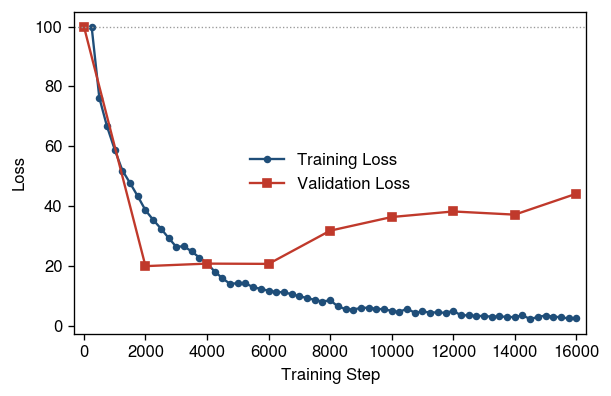

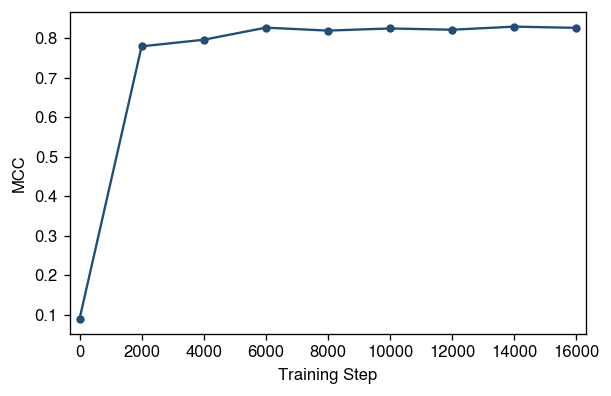

MCC: zero-shot (step 0) 0.089 -> final 0.826


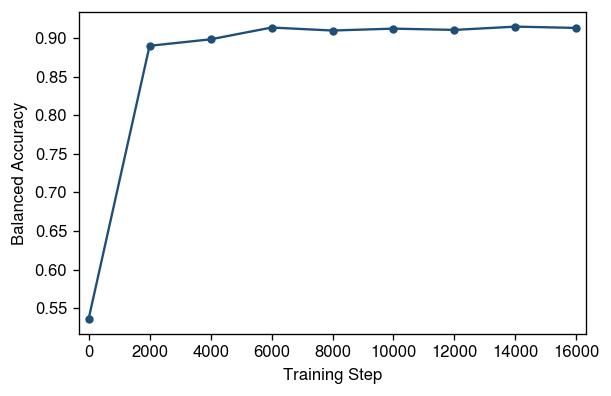

Balanced Accuracy: zero-shot (step 0) 0.536 -> final 0.913


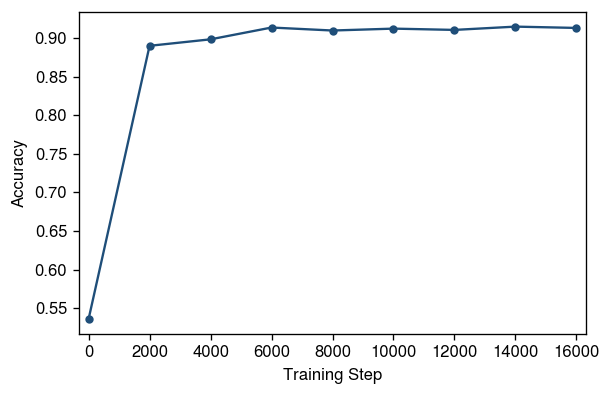

Accuracy: zero-shot (step 0) 0.536 -> final 0.913


In [13]:
# --- 9b · Training curves (paper figures, no title, ONE separate graph per measure) ---
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
import glob as _glob

def set_paper_style(size=10):
    # Professional sans for PoliSci/Econ figures: TeX Gyre Heros (Helvetica clone) first,
    # then Latin Modern Sans, then DejaVu. Install once with the font-install cell above:
    #   !apt-get install -y fonts-texgyre fonts-lmodern
    cand = []
    for pat in ('/usr/share/texmf*/**/texgyreheros-*.otf',      # Debian fonts-texgyre (Heros, not Cn)
                '/usr/share/fonts/**/texgyreheros-*.otf',
                '/usr/share/fonts/**/lmsans*.*', '/usr/share/texmf*/**/lmsans*.otf',
                '/usr/local/share/fonts/**/*.*', '/root/.fonts/**/*.*'):
        cand += _glob.glob(pat, recursive=True)
    got = set()
    for f in sorted(cand):
        if f.lower().endswith(('.otf', '.ttf')):
            try:
                fm.fontManager.addfont(f); got.add(fm.FontProperties(fname=f).get_name())
            except Exception:
                pass
    prefer = ['TeX Gyre Heros', 'Helvetica', 'Latin Modern Sans', 'Arial', 'DejaVu Sans']
    rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': prefer,
        'mathtext.fontset': 'stixsans',
        'font.size': size, 'axes.titlesize': size, 'axes.labelsize': size,
        'xtick.labelsize': size, 'ytick.labelsize': size, 'legend.fontsize': size,
        'axes.linewidth': 0.8, 'savefig.dpi': 300, 'figure.dpi': 120,
    })
    have = got | {f.name for f in fm.fontManager.ttflist}
    active = next((f for f in prefer if f in have), 'DejaVu Sans')
    print('paper font:', active,
          '' if active != 'DejaVu Sans' else '(run the font-install cell for TeX Gyre Heros)')
    return active

set_paper_style(10)
log = pd.DataFrame(trainer.state.log_history)
FIGDIR = REPO / 'scratch/figures'; FIGDIR.mkdir(parents=True, exist_ok=True)

# Figure 1: loss (training + validation), each indexed to 100 at its first value.
tr = (log.dropna(subset=['loss'])[['step', 'loss']].sort_values('step')
      if 'loss' in log else pd.DataFrame())
ev = (log.dropna(subset=['eval_loss'])[['step', 'eval_loss']].sort_values('step')
      if 'eval_loss' in log else pd.DataFrame())
fig, ax = plt.subplots(figsize=(5.2, 3.4))
if len(tr):
    ax.plot(tr['step'], 100*tr['loss'].values/tr['loss'].values[0], color='#1f4e79', lw=1.4,
            marker='o', ms=3.5, label='Training Loss')
if len(ev):
    ax.plot(ev['step'], 100*ev['eval_loss'].values/ev['eval_loss'].values[0], color='#c0392b', lw=1.4,
            marker='s', ms=4.5, label='Validation Loss')
ax.axhline(100, color='0.6', lw=0.8, ls=':')
ax.set_xlabel('Training Step'); ax.set_ylabel('Loss'); ax.legend(frameon=False); ax.margins(x=0.02)
fig.tight_layout(); fig.savefig(FIGDIR / 'stance_nli_loss.pdf', bbox_inches='tight'); plt.show()

# One separate figure per validation measure. The leftmost point (step 0) IS the
# zero-shot baseline -- self-evident from the x-axis, so no special marker or legend.
for col, ylab, fname in [('eval_mcc', 'MCC', 'mcc'),
                         ('eval_balanced_acc', 'Balanced Accuracy', 'balanced_acc'),
                         ('eval_accuracy', 'Accuracy', 'accuracy')]:
    if col not in log:
        continue
    d = log.dropna(subset=[col])[['step', col]].sort_values('step')
    if not len(d):
        continue
    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    ax.plot(d['step'], d[col], color='#1f4e79', lw=1.4, marker='o', ms=4)
    ax.set_xlabel('Training Step'); ax.set_ylabel(ylab); ax.margins(x=0.02)
    fig.tight_layout(); fig.savefig(FIGDIR / f'stance_nli_{fname}.pdf', bbox_inches='tight'); plt.show()
    print(f'{ylab}: zero-shot (step 0) {d[col].values[0]:.3f} -> final {d[col].values[-1]:.3f}')

**Figure note (paper caption).** Training and validation cross-entropy are each *indexed to 100 at the first logged step* and shown as a percentage of that initial value (e.g. 52 means the loss fell to 52% of its starting level). The series are indexed because their absolute levels are not directly comparable: dropout is active during training but disabled at validation, and the training set is oversampled toward the harder minority classes, so the training loss sits higher in absolute terms. Indexing isolates the *relative* decline of each curve. Absolute start/end values are printed beneath the figure.

## 10 · Inference helper + held-out TEST evaluation (T4 production target)

In [23]:
ENT_IDX = model.config.label2id['entailment']

@torch.no_grad()
def score_hypotheses(texts, hyps, batch_size=128, desc='score'):
    '''multi_label=False (HF zero-shot default / Laurer grouped decision): raw ENTAILMENT
    logit per candidate, softmax ACROSS candidates. argmax == argmax of z_entail; z_not-entail unused.'''
    model.eval()
    texts = list(texts); k = len(hyps)
    out = np.zeros((len(texts), k), dtype=np.float32)
    for s in tqdm(range(0, len(texts), batch_size), desc=desc):
        b = texts[s:s+batch_size]
        prem = [t for t in b for _ in range(k)]
        hy   = [h for _ in b for h in hyps]
        enc = tokenizer(prem, hy, truncation=True, max_length=MAX_LENGTH,
                        padding=True, return_tensors='pt').to(DEVICE)
        with torch.autocast('cuda', dtype=torch.float16):
            logits = model(**enc).logits
        zE = logits.float()[:, ENT_IDX].cpu().numpy().reshape(-1, k)   # raw entailment logit/candidate
        zE = zE - zE.max(1, keepdims=True); e = np.exp(zE)
        out[s:s+len(b)] = e / e.sum(1, keepdims=True)                  # softmax ACROSS candidates
    return out

def predict_general(texts, batch_size=128, desc='stance'):
    '''argmax over the 3 general-stance hypotheses -> Left/Right/Neutral + probs.'''
    probs = score_hypotheses(texts, GEN_HYPS, batch_size=batch_size, desc=desc)
    pred = np.array(LRN_ORDER)[probs.argmax(1)]
    return pred, probs

In [24]:
test_gen = split_test[split_test['gen_label'].notna()].copy()
pred, probs = predict_general(test_gen['text'].tolist(), batch_size=EVAL_BS, desc='test T4')
test_gen = test_gen.assign(pred=pred, p_left=probs[:,0], p_right=probs[:,1], p_neutral=probs[:,2])
test_gen.to_csv(TEST_PRED, index=False)
print('saved test predictions ->', TEST_PRED, '| n =', len(test_gen))

test T4:   0%|          | 0/17 [00:00<?, ?it/s]

saved test predictions -> /content/drive/MyDrive/Papers/transfer_learning/topic2irt/data/processed/stance_nli_test_predictions.csv | n = 4172


In [26]:
# Routed L/R/N from the SAVED trained model (loaded fresh from MODEL_DIR).
# topic -> (econ stance | soc stance) -> derive Left/Right/Neutral. Direct vs routed, same model.
# Scoring = multi_label=False (zero-shot default), matching score_hypotheses.
from transformers import AutoModelForSequenceClassification as _AM, AutoTokenizer as _AT
import torch
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score, classification_report, confusion_matrix

_tok = _AT.from_pretrained(MODEL_DIR)
_mdl = _AM.from_pretrained(MODEL_DIR).to(DEVICE).eval()
_ent = _mdl.config.label2id['entailment']

@torch.no_grad()
def _scores(texts, hyps, bs=EVAL_BS):
    K = len(hyps); texts = list(texts); out = np.zeros((len(texts), K), np.float32)
    for s in range(0, len(texts), bs):
        b = texts[s:s+bs]; prem = [t for t in b for _ in range(K)]; hy = [h for _ in b for h in hyps]
        enc = _tok(prem, hy, truncation=True, max_length=MAX_LENGTH, padding=True, return_tensors='pt').to(DEVICE)
        with torch.autocast('cuda', dtype=torch.float16):
            logits = _mdl(**enc).logits
        zE = logits.float()[:, _ent].cpu().numpy().reshape(-1, K)   # raw entailment logit / candidate
        zE = zE - zE.max(1, keepdims=True); e = np.exp(zE)
        out[s:s+len(b)] = e / e.sum(1, keepdims=True)               # softmax ACROSS candidates
    return out

txt = test_gen['text'].tolist()
yg  = test_gen['gen_label'].values
TO, EO, SO = (list(TASKS['topic']['options']), list(TASKS['econ']['options']), list(TASKS['soc']['options']))
tp = np.array(TO)[_scores(txt, [hyp('topic', o) for o in TO]).argmax(1)]
ep = np.array(EO)[_scores(txt, [hyp('econ',  o) for o in EO]).argmax(1)]
sp = np.array(SO)[_scores(txt, [hyp('soc',   o) for o in SO]).argmax(1)]
direct = np.array(LRN_ORDER)[_scores(txt, GEN_HYPS).argmax(1)]

ECON2 = {'State': 'Left', 'Market': 'Right', 'Neutral': 'Neutral'}
SOC2  = {'Progressive': 'Left', 'Conservative': 'Right', 'Neutral': 'Neutral'}
routed = np.array([ECON2[e] if t == 'Economy' else SOC2[s] for t, e, s in zip(tp, ep, sp)])

print('SAVED model = %s, multi_label=False (zero-shot default)  (n=%d test)' % (MODEL_NAME, len(yg)))
print('  DIRECT  L/R/N : MCC=%.3f  balanced_acc=%.3f' %
      (matthews_corrcoef(yg, direct), balanced_accuracy_score(yg, direct)))
print('  ROUTED  L/R/N : MCC=%.3f  balanced_acc=%.3f' %
      (matthews_corrcoef(yg, routed), balanced_accuracy_score(yg, routed)))
print('\nROUTED per-class:')
print(classification_report(yg, routed, labels=LRN_ORDER, digits=3, zero_division=0))
print('ROUTED confusion (rows=gold, cols=pred)', LRN_ORDER)
print(confusion_matrix(yg, routed, labels=LRN_ORDER))
del _mdl; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

SAVED model = MoritzLaurer/bge-m3-zeroshot-v2.0, multi_label=False (zero-shot default)  (n=4172 test)
  DIRECT  L/R/N : MCC=0.748  balanced_acc=0.829
  ROUTED  L/R/N : MCC=0.743  balanced_acc=0.824

ROUTED per-class:
              precision    recall  f1-score   support

        Left      0.848     0.858     0.853      1802
       Right      0.805     0.761     0.783       929
     Neutral      0.835     0.852     0.844      1441

    accuracy                          0.835      4172
   macro avg      0.830     0.824     0.826      4172
weighted avg      0.834     0.835     0.834      4172

ROUTED confusion (rows=gold, cols=pred) ['Left', 'Right', 'Neutral']
[[1547  108  147]
 [ 127  707   95]
 [ 150   63 1228]]


### 10b · T4 metrics — macro-F1 overall, per language, per L/R/N  *(cheap)*

In [27]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             matthews_corrcoef, balanced_accuracy_score)
y, yh = test_gen['gen_label'].values, test_gen['pred'].values
mcc  = matthews_corrcoef(y, yh)
bacc = balanced_accuracy_score(y, yh)
print('T4 TEST  (trinary L/R/N argmax inference)  n=%d' % len(y))
print('  MCC               : %.3f' % mcc)
print('  Balanced accuracy : %.3f' % bacc)
print('\nper-class precision / recall / F1 (diagnostic only):')
print(classification_report(y, yh, labels=LRN_ORDER, digits=3))
print('per-language balanced accuracy:')
lang_rows = []
for lg, d in test_gen.groupby('language'):
    if len(d) < 10:
        print(f'  {lg:<12} n={len(d)} (skip)'); continue
    b = balanced_accuracy_score(d['gen_label'], d['pred'])
    lang_rows.append((lg, len(d), b)); print(f'  {lg:<12} n={len(d):<5} balanced_acc={b:.3f}')
print('\nconfusion (rows=gold, cols=pred)', LRN_ORDER); print(confusion_matrix(y, yh, labels=LRN_ORDER))

T4 TEST  (trinary L/R/N argmax inference)  n=4172
  MCC               : 0.748
  Balanced accuracy : 0.829

per-class precision / recall / F1 (diagnostic only):
              precision    recall  f1-score   support

        Left      0.861     0.850     0.855      1802
       Right      0.802     0.772     0.787       929
     Neutral      0.831     0.864     0.847      1441

    accuracy                          0.837      4172
   macro avg      0.831     0.829     0.830      4172
weighted avg      0.837     0.837     0.837      4172

per-language balanced accuracy:
  catalan      n=443   balanced_acc=0.857
  english      n=368   balanced_acc=0.821
  french       n=211   balanced_acc=0.811
  galician     n=199   balanced_acc=0.764
  german       n=651   balanced_acc=0.793
  italian      n=1088  balanced_acc=0.838
  portuguese   n=282   balanced_acc=0.815
  spanish      n=512   balanced_acc=0.849
  swedish      n=418   balanced_acc=0.854

confusion (rows=gold, cols=pred) ['Left', 'Right

### 10c · Auxiliary tasks on test (T1 topic / T2 econ / T3 soc)  *(cheap, sanity)*

In [29]:
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score
for task in ['topic', 'econ', 'soc']:
    col, opts = TASKS[task]['col'], list(TASKS[task]['options'])
    d = split_test[split_test[col].notna()]
    if len(d) < 10:
        print(f'{task}: too few test rows'); continue
    hyps = [hyp(task, o) for o in opts]
    pr = np.array(opts)[score_hypotheses(d['text'].tolist(), hyps, batch_size=EVAL_BS, desc=task).argmax(1)]
    print(f'{task:<6} n={len(d):<5} MCC={matthews_corrcoef(d[col].values, pr):.3f}  '
          f'balanced_acc={balanced_accuracy_score(d[col].values, pr):.3f}')

topic:   0%|          | 0/25 [00:00<?, ?it/s]

topic  n=6176  MCC=0.880  balanced_acc=0.940


econ:   0%|          | 0/7 [00:00<?, ?it/s]

econ   n=1678  MCC=0.760  balanced_acc=0.843


soc:   0%|          | 0/7 [00:00<?, ?it/s]

soc    n=1626  MCC=0.765  balanced_acc=0.838


### 10d · Plots  *(cheap, separate cell)*

paper font: TeX Gyre Heros 


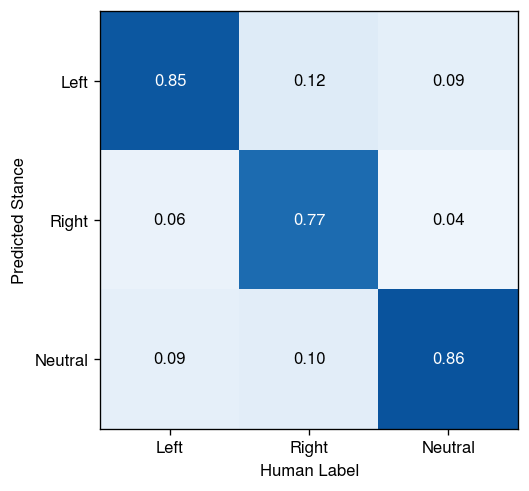

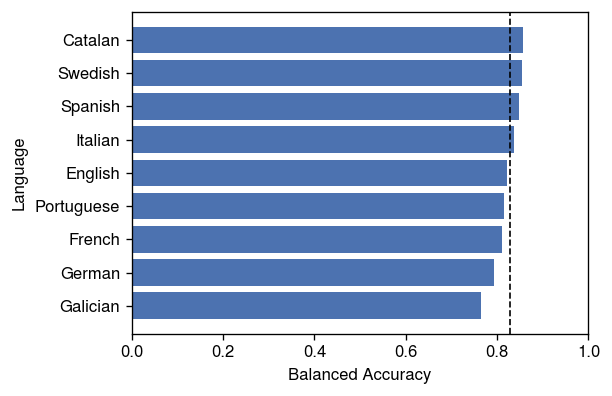

Dashed line = overall balanced accuracy across all languages: 0.829


In [28]:
# --- 10d · Test diagnostics: TWO independent figures (each its own PDF) ---
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
try:
    set_paper_style()
except NameError:
    pass
FIGDIR = REPO / 'scratch/figures'; FIGDIR.mkdir(parents=True, exist_ok=True)

# Figure A: confusion matrix. Human/gold on x-axis, predicted on y-axis
# (row-normalised by gold, then transposed). Self-contained.
fig, ax = plt.subplots(figsize=(4.6, 4.2))
cm = confusion_matrix(y, yh, labels=LRN_ORDER).astype(float)
disp = (cm / cm.sum(1, keepdims=True)).T
im = ax.imshow(disp, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(LRN_ORDER)
ax.set_yticks(range(3)); ax.set_yticklabels(LRN_ORDER)
ax.set_xlabel('Human Label'); ax.set_ylabel('Predicted Stance')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{disp[i,j]:.2f}', ha='center', va='center',
                color='white' if disp[i,j] > .5 else 'black')
fig.tight_layout()
fig.savefig(FIGDIR / 'stance_nli_confusion.pdf', bbox_inches='tight')
plt.show()

# Figure B: per-language balanced accuracy. Self-contained.
# Dashed line = overall balanced accuracy. No in-plot legend (it floated/overlapped the
# bars and was hard to keep well-positioned); the value is printed as text below instead.
if lang_rows:
    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    lg = [r[0].capitalize() for r in lang_rows]; vv = [r[2] for r in lang_rows]; o = np.argsort(vv)
    ax.barh([lg[i] for i in o], [vv[i] for i in o], color='#4C72B0')
    ax.axvline(bacc, color='k', ls='--', lw=1)
    ax.set_xlim(0, 1); ax.set_xlabel('Balanced Accuracy'); ax.set_ylabel('Language')
    fig.tight_layout()
    fig.savefig(FIGDIR / 'stance_nli_lang_balanced_acc.pdf', bbox_inches='tight')
    plt.show()
    print('Dashed line = overall balanced accuracy across all languages: %.3f' % bacc)

paper font: TeX Gyre Heros 


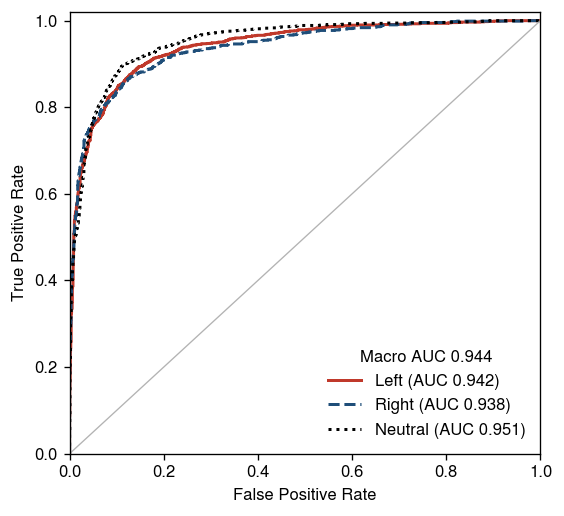

per-class AUC : {'Left': np.float64(0.942), 'Right': np.float64(0.938), 'Neutral': np.float64(0.951)}
macro AUC     : 0.944
micro AUC     : 0.944


In [30]:
# --- 10e · ROC curves + AUC (one-vs-rest per stance) ---
# Scores are P(entailment) per T4 hypothesis (p_left/p_right/p_neutral), already on test_gen.
# Each class -> binary one-vs-rest ROC; report per-class AUC + macro/micro averages.
# B&W-friendly: full [0,1] view, classes separated by SOLID / DASHED / DOTTED linestyle
# (+ luminance-distinct colors). Linestyle reads even where the curves overlap in the corner.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
try:
    set_paper_style()
except NameError:
    pass

SCORE_COL = {'Left': 'p_left', 'Right': 'p_right', 'Neutral': 'p_neutral'}
STYLE = {'Left':    dict(color='#c0392b', ls='-'),    # solid
         'Right':   dict(color='#1f4e79', ls='--'),   # dashed
         'Neutral': dict(color='black',   ls=':')}     # dotted
y_true = test_gen['gen_label'].values
Y = label_binarize(y_true, classes=LRN_ORDER)                 # (n, 3) one-hot gold
S = test_gen[[SCORE_COL[c] for c in LRN_ORDER]].values        # (n, 3) entailment scores

fig, ax = plt.subplots(figsize=(4.8, 4.4))
aucs = {}
for k, c in enumerate(LRN_ORDER):                              # Neutral (dotted) drawn last -> on top
    fpr, tpr, _ = roc_curve(Y[:, k], S[:, k])
    aucs[c] = roc_auc_score(Y[:, k], S[:, k])
    ax.plot(fpr, tpr, lw=1.8, label=f'{c} (AUC {aucs[c]:.3f})', **STYLE[c])
macro = roc_auc_score(Y, S, average='macro')
micro = roc_auc_score(Y, S, average='micro')
ax.plot([0, 1], [0, 1], color='0.7', lw=0.8)                  # chance (thin grey solid)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(frameon=False, loc='lower right', title=f'Macro AUC {macro:.3f}')
fig.tight_layout()
FIGDIR = REPO / 'scratch/figures'; FIGDIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGDIR / 'stance_nli_roc.pdf', bbox_inches='tight')
plt.show()
print('per-class AUC :', {c: round(v, 3) for c, v in aucs.items()})
print('macro AUC     : %.3f' % macro)
print('micro AUC     : %.3f' % micro)

In [31]:
# --- 10f · Inference-time recalibration (NO retrain): fix Right's over-firing ---
# Oversampling balanced Right's RECALL (0.825) at the cost of PRECISION (0.736): the Right
# head over-fires, so ~140 Left + ~135 Neutral leak in as false positives. But Right's AUC is
# 0.935 (2nd best) -> the RANKING is fine; only the argmax operating point is wrong. So fit a
# per-class additive offset on the VALIDATION split (Left fixed at 0) to maximize val MCC, then
# apply the SAME offsets to TEST. Decision-rule fix, not a model change; no cheating (fit!=eval).
from itertools import product
from sklearn.metrics import (matthews_corrcoef, classification_report,
                             balanced_accuracy_score, confusion_matrix)

val_gen = split_val[split_val['gen_label'].notna()].copy()
_, vp = predict_general(val_gen['text'].tolist(), batch_size=EVAL_BS, desc='val T4')  # (n,3) L/R/N probs
yv = val_gen['gen_label'].values
yt = test_gen['gen_label'].values
St = test_gen[['p_left', 'p_right', 'p_neutral']].values

grid = np.round(np.arange(-0.30, 0.301, 0.02), 3)
best = (-1.0, 0.0, 0.0)
for bR, bN in product(grid, grid):
    pv = np.array(LRN_ORDER)[(vp - np.array([0.0, bR, bN])).argmax(1)]
    m = matthews_corrcoef(yv, pv)
    if m > best[0]:
        best = (m, bR, bN)
_, bR, bN = best
yh_cal = np.array(LRN_ORDER)[(St - np.array([0.0, bR, bN])).argmax(1)]

print('fitted offsets (on VAL):  Left 0.00  Right %+.2f  Neutral %+.2f   (val MCC %.3f)' % (bR, bN, best[0]))
print('\nTEST baseline argmax :  MCC %.3f  balanced_acc %.3f' %
      (matthews_corrcoef(yt, test_gen['pred'].values),
       balanced_accuracy_score(yt, test_gen['pred'].values)))
print('TEST recalibrated    :  MCC %.3f  balanced_acc %.3f' %
      (matthews_corrcoef(yt, yh_cal), balanced_accuracy_score(yt, yh_cal)))
print('\nrecalibrated per-class (TEST):')
print(classification_report(yt, yh_cal, labels=LRN_ORDER, digits=3, zero_division=0))
print('recalibrated confusion (rows=gold, cols=pred)', LRN_ORDER)
print(confusion_matrix(yt, yh_cal, labels=LRN_ORDER))

val T4:   0%|          | 0/20 [00:00<?, ?it/s]

fitted offsets (on VAL):  Left 0.00  Right +0.00  Neutral +0.30   (val MCC 0.763)

TEST baseline argmax :  MCC 0.748  balanced_acc 0.829
TEST recalibrated    :  MCC 0.744  balanced_acc 0.826

recalibrated per-class (TEST):
              precision    recall  f1-score   support

        Left      0.854     0.853     0.854      1802
       Right      0.793     0.773     0.783       929
     Neutral      0.838     0.853     0.846      1441

    accuracy                          0.835      4172
   macro avg      0.829     0.826     0.827      4172
weighted avg      0.835     0.835     0.835      4172

recalibrated confusion (rows=gold, cols=pred) ['Left', 'Right', 'Neutral']
[[1538  119  145]
 [ 119  718   92]
 [ 144   68 1229]]


## 11 · Save model + tokenizer + metadata

In [33]:
model.save_pretrained(MODEL_DIR); tokenizer.save_pretrained(MODEL_DIR)
meta = dict(model_name=MODEL_NAME, max_length=MAX_LENGTH, id2label=ID2LABEL,
            lrn_order=LRN_ORDER, general_hypotheses=GEN_HYPS,
            tasks={k: {'template': v['template'], 'options': v['options']} for k, v in TASKS.items()},
            oversample=OVERSAMPLE, negatives=NEGATIVES, use_english=USE_ENGLISH, lr=LR,
            smoke=SMOKE, random_state=RANDOM_STATE,
            test_mcc=float(mcc), test_balanced_acc=float(bacc))
(MODEL_DIR / 'stance_nli_meta.json').write_text(json.dumps(meta, indent=2, ensure_ascii=False))
print('saved ->', MODEL_DIR)
print('NOTE: SMOKE=%s. Re-run with SMOKE=False for the full model before inference.' % SMOKE)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved -> /content/drive/MyDrive/Papers/transfer_learning/topic2irt/models/stance_nli_bgem3
NOTE: SMOKE=False. Re-run with SMOKE=False for the full model before inference.
